In [1]:
from IPython.display import Markdown, display

display(Markdown("""
# Diabetic Retinopathy Detection and Classification using EfficientNetB3

This notebook performs **Diabetic Retinopathy Detection and Classification** using the APTOS 2019 Blindness Detection dataset.

Original APTOS classes:

| Original Class | Meaning |
|---|---|
| 0 | No Diabetic Retinopathy |
| 1 | Mild DR |
| 2 | Moderate DR |
| 3 | Severe DR |
| 4 | Proliferative DR |

Converted binary classes:

| New Class | Meaning |
|---|---|
| 0 | No DR |
| 1 | DR Present |

This version is code-safe for Kaggle. Every section will run as Python code.
"""))


# Diabetic Retinopathy Detection and Classification using EfficientNetB3

This notebook performs **Diabetic Retinopathy Detection and Classification** using the APTOS 2019 Blindness Detection dataset.

Original APTOS classes:

| Original Class | Meaning |
|---|---|
| 0 | No Diabetic Retinopathy |
| 1 | Mild DR |
| 2 | Moderate DR |
| 3 | Severe DR |
| 4 | Proliferative DR |

Converted binary classes:

| New Class | Meaning |
|---|---|
| 0 | No DR |
| 1 | DR Present |

This version is code-safe for Kaggle. Every section will run as Python code.


In [2]:
# ===============================
# 1. Import Required Libraries
# ===============================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))




TRAIN_CSV =  "train.csv"
IMAGE_DIR = "train_images"

TensorFlow version: 2.21.0
GPU Available: []


In [3]:
# ===============================
# 3. Load Dataset
# ===============================

df = pd.read_csv("train.csv")
df["filename"] = df["id_code"].astype(str) + ".png"

# Convert 5-class labels to binary labels
# 0 = No DR
# 1 = DR Present
df["binary_diagnosis"] = df["diagnosis"].apply(lambda x: 0 if x == 0 else 1).astype(int)

print("Dataset Preview:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nOriginal 5-Class Distribution:")
display(df["diagnosis"].value_counts().sort_index().to_frame("count"))

print("\nBinary Class Distribution:")
display(df["binary_diagnosis"].value_counts().sort_index().to_frame("count"))

Dataset Preview:


,id_code,diagnosis,filename,binary_diagnosis
0,000c1434d8d7,2,000c1434d8d7.png,1
1,001639a390f0,4,001639a390f0.png,1
2,0024cdab0c1e,1,0024cdab0c1e.png,1
3,002c21358ce6,0,002c21358ce6.png,0
4,005b95c28852,0,005b95c28852.png,0



Dataset Shape: (3662, 4)

Original 5-Class Distribution:


,count
diagnosis,
0,1805
1,370
2,999
3,193
4,295



Binary Class Distribution:


,count
binary_diagnosis,
0,1805
1,1857


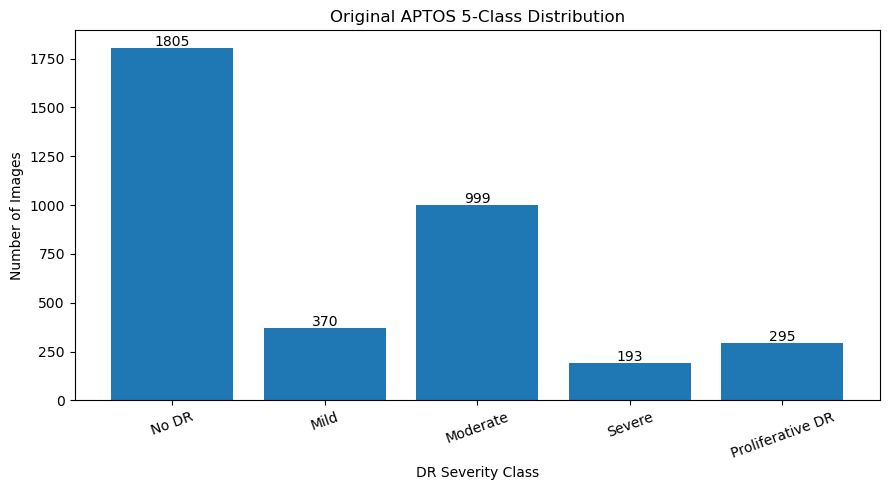

In [4]:
# ===============================
# 4. Original 5-Class Distribution Graph
# ===============================

original_counts = df["diagnosis"].value_counts().sort_index()
original_labels = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

plt.figure(figsize=(9, 5))
bars = plt.bar(original_labels, original_counts.values)
plt.title("Original APTOS 5-Class Distribution")
plt.xlabel("DR Severity Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(int(height)), ha="center")

plt.tight_layout()
plt.show()

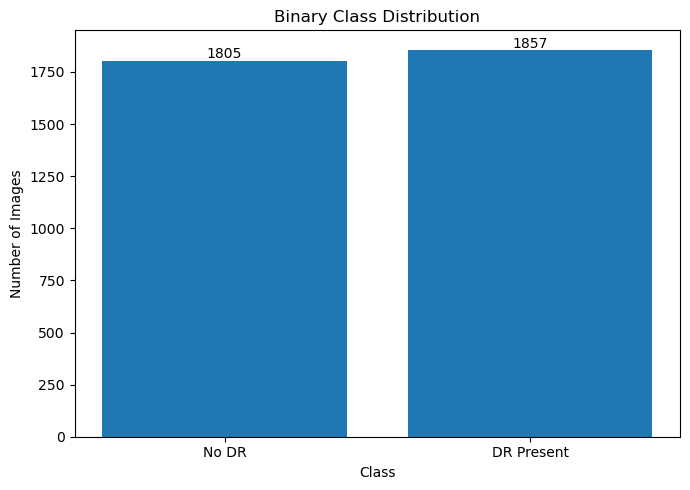

In [5]:
# ===============================
# 5. Binary Class Distribution Graph
# ===============================

binary_counts = df["binary_diagnosis"].value_counts().sort_index()
binary_labels = ["No DR", "DR Present"]

plt.figure(figsize=(7, 5))
bars = plt.bar(binary_labels, binary_counts.values)
plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(int(height)), ha="center")

plt.tight_layout()
plt.show()

Image not found: train_images\0a85a1e8f9e9.png
Image not found: train_images\3e3a3955b9c5.png


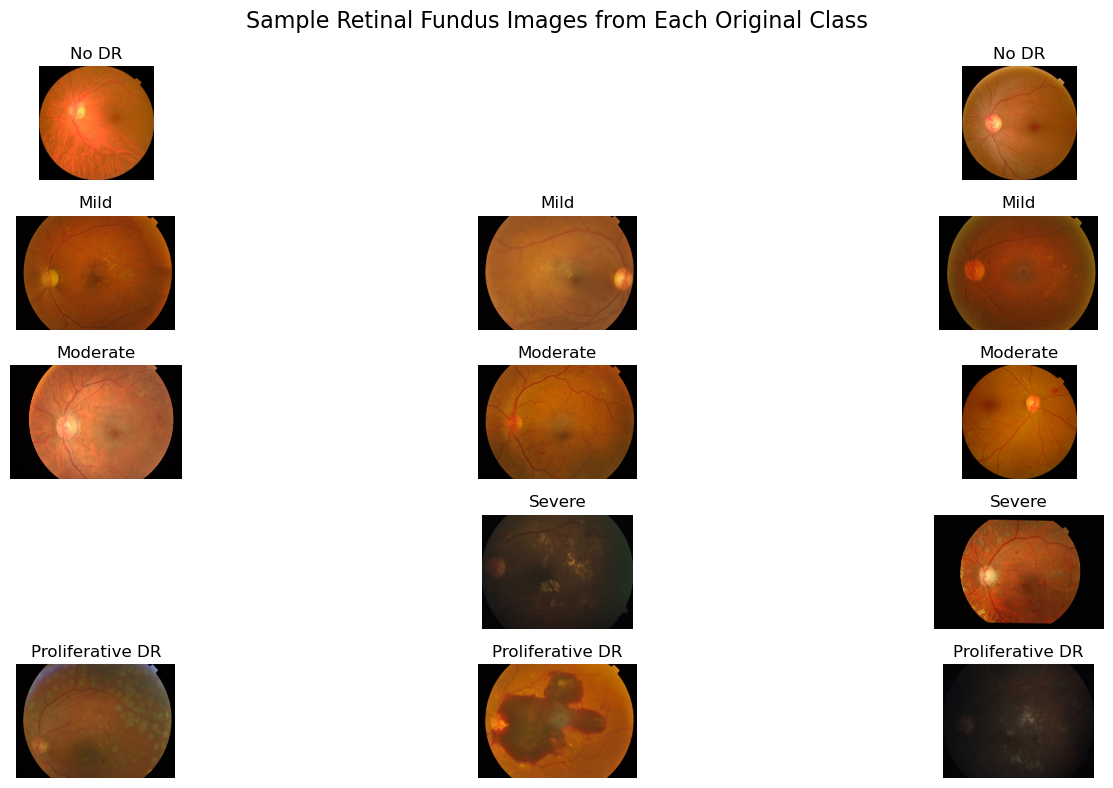

In [6]:
# ===============================
# 6. Show Sample Images from Original 5 Classes
# ===============================
plt.figure(figsize=(15, 8))

for class_id in range(5):
    class_samples = df[df["diagnosis"] == class_id].sample(3, random_state=SEED)
    for j, (_, row) in enumerate(class_samples.iterrows()):
        img_path = os.path.join(IMAGE_DIR, row["filename"])
        img = cv2.imread(img_path)
        if img is None:
        
            print("Image not found:", img_path)
            continue


        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    

        index = class_id * 3 + j + 1
        plt.subplot(5, 3, index)
        plt.imshow(img)
        plt.title(f"{original_labels[class_id]}")
        plt.axis("off")

plt.suptitle("Sample Retinal Fundus Images from Each Original Class", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'sample_submission.csv', 'test.csv', 'test_images', 'train.csv', 'train_images', 'Untitled.ipynb']


Image not found: train_images\0a85a1e8f9e9.png
Image not found: train_images\1f0e223b8055.png


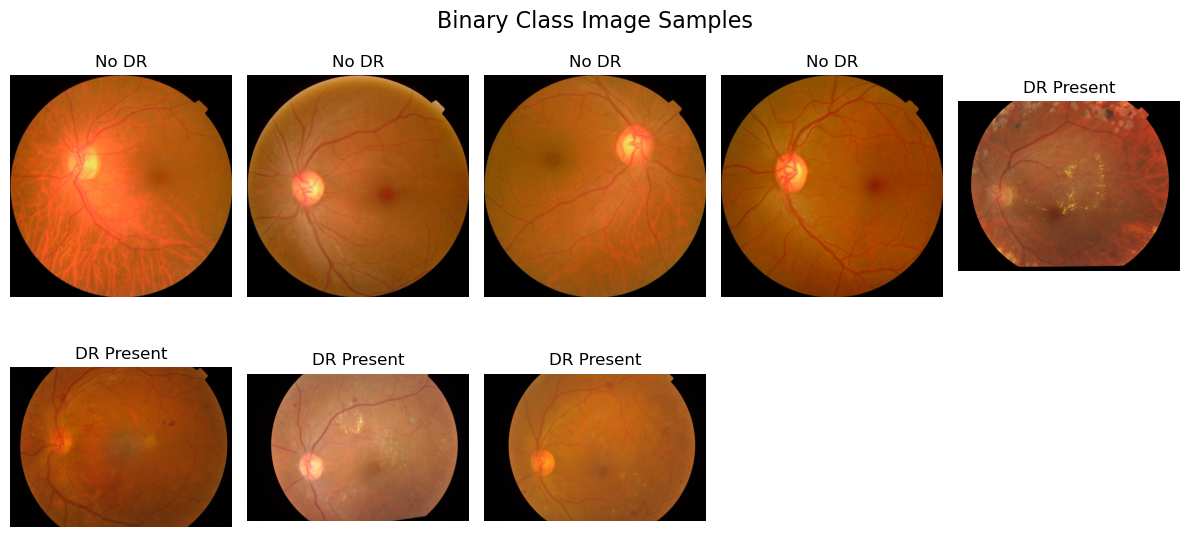

In [8]:
# ===============================
# 7. Show Sample Images from Binary Classes
# ===============================

plt.figure(figsize=(12, 6))

plot_index = 1
for class_id in [0, 1]:
    class_samples = df[df["binary_diagnosis"] == class_id].sample(5, random_state=SEED)
    for _, row in class_samples.iterrows():
        img_path = os.path.join(IMAGE_DIR, row["filename"])
        img = cv2.imread(img_path)
        if img is None:
            print("Image not found:", img_path)
            continue
       
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, plot_index)
        plt.imshow(img)
        plt.title(binary_labels[class_id])
        plt.axis("off")
        plot_index += 1

plt.suptitle("Binary Class Image Samples", fontsize=16)
plt.tight_layout()
plt.show()

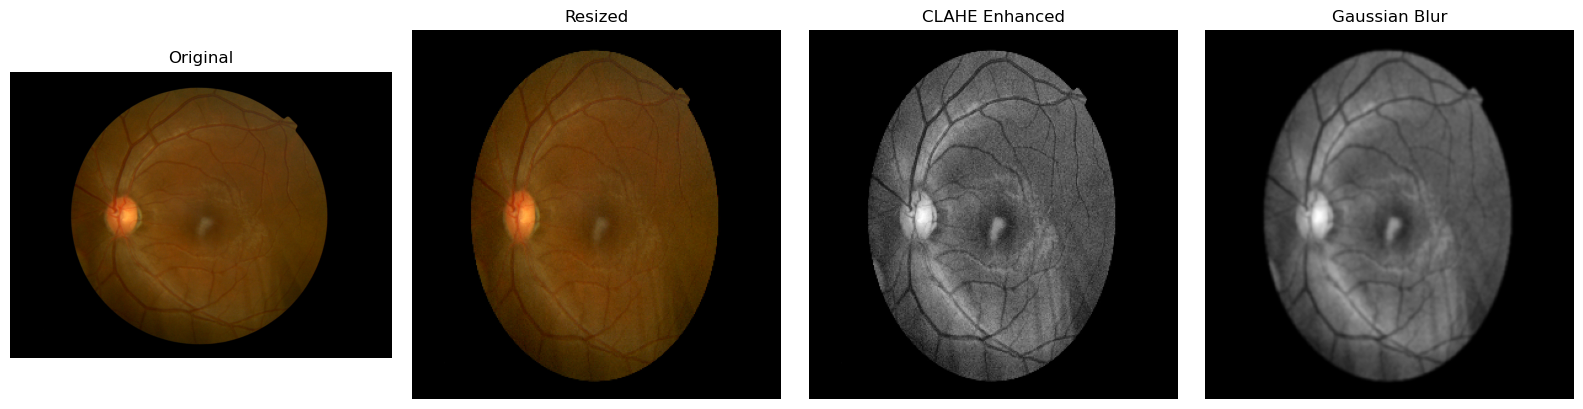

In [9]:
# ===============================
# 8. Preprocessing Visualization
# ===============================

IMG_SIZE = 300
BATCH_SIZE = 16

def display_preprocessing_steps(image_path):
    original_bgr = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(original_rgb, (IMG_SIZE, IMG_SIZE))

    green_channel = resized[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(green_channel)

    blurred = cv2.GaussianBlur(clahe_img, (5, 5), 0)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(resized)
    plt.title("Resized")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(clahe_img, cmap="gray")
    plt.title("CLAHE Enhanced")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(blurred, cmap="gray")
    plt.title("Gaussian Blur")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

sample_image_path = os.path.join(IMAGE_DIR, df.sample(1, random_state=SEED).iloc[0]["filename"])
display_preprocessing_steps(sample_image_path)

In [10]:
# ===============================
# 9. Train Validation Split
# ===============================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["binary_diagnosis"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

print("\nTraining Distribution:")
display(train_df["binary_diagnosis"].value_counts().sort_index().to_frame("count"))

print("\nValidation Distribution:")
display(val_df["binary_diagnosis"].value_counts().sort_index().to_frame("count"))

Training samples: 2929
Validation samples: 733

Training Distribution:


,count
binary_diagnosis,
0,1444
1,1485



Validation Distribution:


,count
binary_diagnosis,
0,361
1,372


In [11]:
# ===============================
# 10. Data Augmentation Setup
# ===============================

train_datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="filename",
    y_col="binary_diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="filename",
    y_col="binary_diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2929 validated image filenames.
Found 733 validated image filenames.


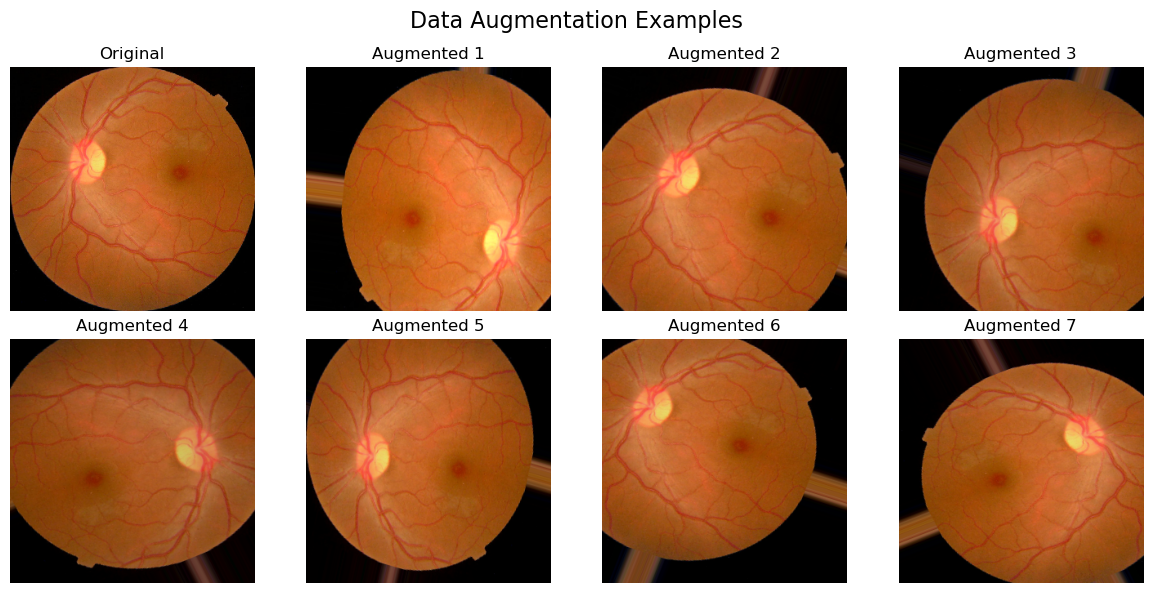

In [12]:
# ===============================
# 11. Visualize Augmented Images
# ===============================

sample_row = train_df.sample(1, random_state=SEED).iloc[0]
sample_img_path = os.path.join(IMAGE_DIR, sample_row["filename"])

img = tf.keras.preprocessing.image.load_img(sample_img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

aug_iter = train_datagen.flow(img_array, batch_size=1, seed=SEED)

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

for i in range(7):
    aug_img = next(aug_iter)[0].astype("uint8")
    plt.subplot(2, 4, i + 2)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# ===============================
# 12. Build EfficientNetB3 Model
# ===============================

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 300, 300, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 300, 300, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 300, 300, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 300, 300, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 301, 301, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 150, 150, 40)      │           1,080 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 150, 150, 40)      │             160 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 150, 150, 40)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 150, 150, 40)      │             360 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 150, 150, 40)      │             160 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 150, 150, 40)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 40)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 40)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 10)          │             410 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 40)          │             440 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 11,579,184 (44.17 MB)

 Trainable params: 791,553 (3.02 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

In [14]:
# ===============================
# 13. Class Weights
# ===============================

classes = np.unique(train_df["binary_diagnosis"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["binary_diagnosis"]
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.014196675900277), np.int64(1): np.float64(0.9861952861952862)}


In [15]:
# ===============================
# 14. Training Callbacks
# ===============================

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        filepath="best_dr_detection_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

In [16]:
# ===============================
# 15. Initial Training
# ===============================

EPOCHS = 25

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 681s 4s/step - accuracy: 0.8573 - loss: 0.3422 - val_accuracy: 0.9359 - val_loss: 0.2320 - learning_rate: 1.0000e-04
Epoch 2/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 635s 3s/step - accuracy: 0.9095 - loss: 0.2329 - val_accuracy: 0.9468 - val_loss: 0.1417 - learning_rate: 1.0000e-04
Epoch 3/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 629s 3s/step - accuracy: 0.9228 - loss: 0.2215 - val_accuracy: 0.9577 - val_loss: 0.1101 - learning_rate: 1.0000e-04
Epoch 4/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 627s 3s/step - accuracy: 0.9280 - loss: 0.2071 - val_accuracy: 0.9632 - val_loss: 0.0914 - learning_rate: 1.0000e-04
Epoch 5/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 627s 3s/step - accuracy: 0.9358 - loss: 0.1800 - val_accuracy: 0.9604 - val_loss: 0.0960 - learning_rate: 1.0000e-04
Epoch 6/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 626s 3s/step - accuracy: 0.9256 - loss: 0.1866 - val_accuracy: 0.9618 - val_loss: 0.0854 - learning_rate: 1.0000e-04
Epoch 7/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 627s 3s/step - acc

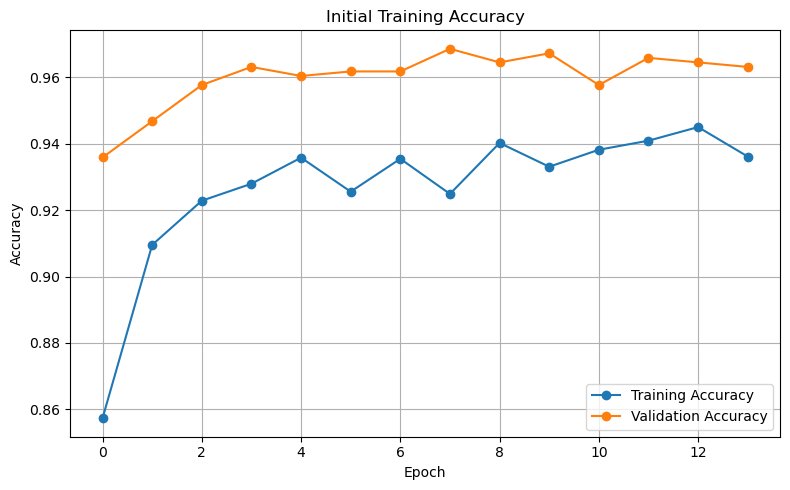

In [17]:
# ===============================
# 16. Initial Training Accuracy Graph
# ===============================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

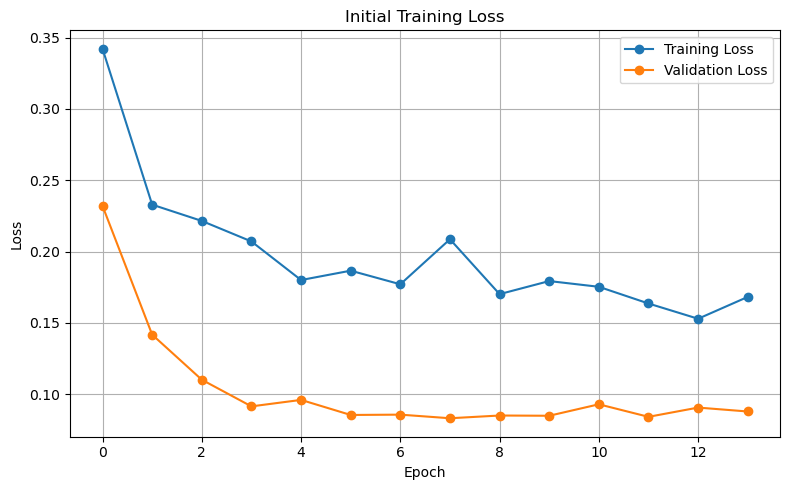

In [18]:
# ===============================
# 17. Initial Training Loss Graph
# ===============================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# ===============================
# 18. Fine Tuning
# ===============================

base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 784s 4s/step - accuracy: 0.9044 - loss: 0.2400 - val_accuracy: 0.9482 - val_loss: 0.1290 - learning_rate: 1.0000e-05
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 755s 4s/step - accuracy: 0.9177 - loss: 0.2181 - val_accuracy: 0.9345 - val_loss: 0.1552 - learning_rate: 1.0000e-05
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 754s 4s/step - accuracy: 0.9304 - loss: 0.1891 - val_accuracy: 0.9523 - val_loss: 0.1202 - learning_rate: 1.0000e-05
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 754s 4s/step - accuracy: 0.9358 - loss: 0.1821 - val_accuracy: 0.9536 - val_loss: 0.1180 - learning_rate: 2.0000e-06
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 754s 4s/step - accuracy: 0.9293 - loss: 0.2137 - val_accuracy: 0.9536 - val_loss: 0.1163 - learning_rate: 2.0000e-06
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 758s 4s/step - accuracy: 0.9300 - loss: 0.1894 - val_accuracy: 0.9591 - val_loss: 0.1142 - learning_rate: 2.0000e-06


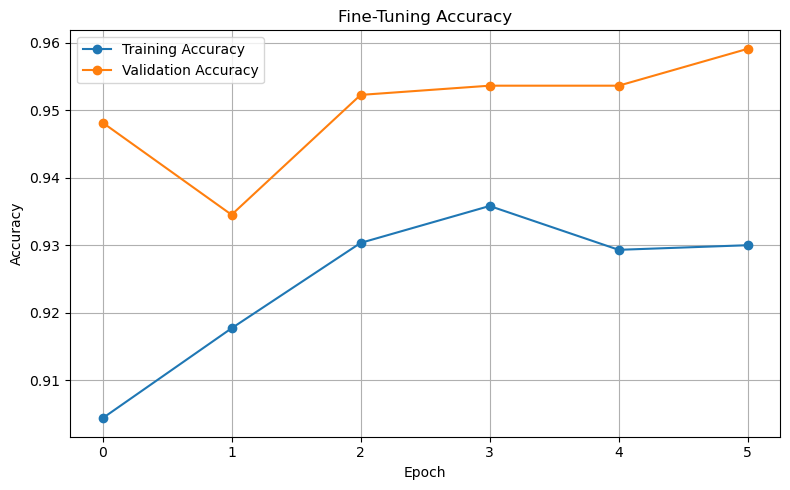

In [20]:
# ===============================
# 19. Fine Tuning Accuracy Graph
# ===============================

plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

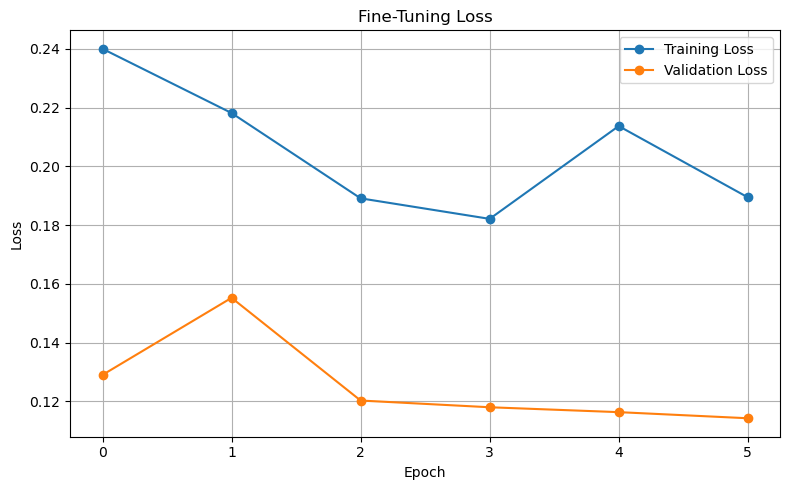

In [21]:
# ===============================
# 20. Fine Tuning Loss Graph
# ===============================

plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["loss"], marker="o", label="Training Loss")
plt.plot(fine_tune_history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

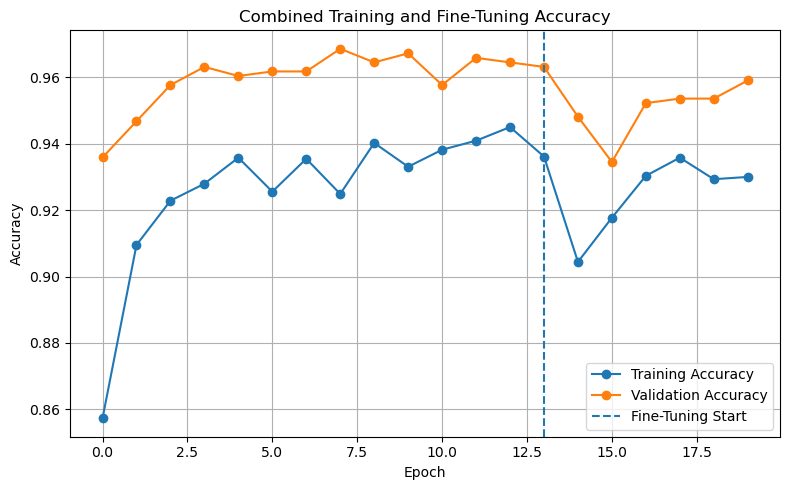

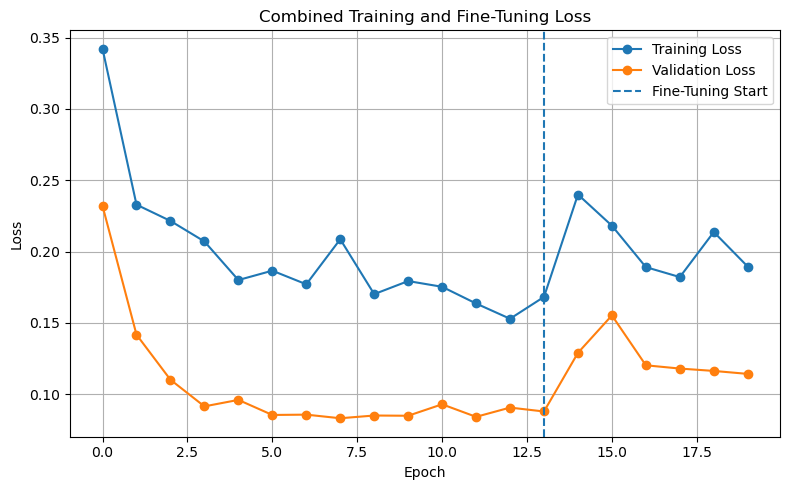

In [22]:
# ===============================
# 21. Combined Training Graphs
# ===============================

combined_acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
combined_val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]
combined_loss = history.history["loss"] + fine_tune_history.history["loss"]
combined_val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(combined_acc, marker="o", label="Training Accuracy")
plt.plot(combined_val_acc, marker="o", label="Validation Accuracy")
plt.axvline(x=len(history.history["accuracy"]) - 1, linestyle="--", label="Fine-Tuning Start")
plt.title("Combined Training and Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(combined_loss, marker="o", label="Training Loss")
plt.plot(combined_val_loss, marker="o", label="Validation Loss")
plt.axvline(x=len(history.history["loss"]) - 1, linestyle="--", label="Fine-Tuning Start")
plt.title("Combined Training and Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# ===============================
# 22. Final Evaluation
# ===============================

val_gen.reset()

tta_steps = 5
tta_predictions = []

for i in range(tta_steps):
    val_gen.reset()
    pred_prob = model.predict(val_gen, verbose=1)
    tta_predictions.append(pred_prob)

y_pred_prob = np.mean(tta_predictions, axis=0).reshape(-1)
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = val_df["binary_diagnosis"].values

cnn_accuracy = accuracy_score(y_true, y_pred) * 100
cnn_precision = precision_score(y_true, y_pred, zero_division=0) * 100
cnn_recall = recall_score(y_true, y_pred, zero_division=0) * 100
cnn_f1 = f1_score(y_true, y_pred, zero_division=0) * 100
cnn_auc = roc_auc_score(y_true, y_pred_prob) * 100

print("Final Actual Validation Results")
print("--------------------------------")
print(f"Accuracy : {cnn_accuracy:.2f}%")
print(f"Precision: {cnn_precision:.2f}%")
print(f"Recall   : {cnn_recall:.2f}%")
print(f"F1-Score : {cnn_f1:.2f}%")
print(f"ROC-AUC  : {cnn_auc:.2f}%")

46/46 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step
Final Actual Validation Results
--------------------------------
Accuracy : 94.82%
Precision: 97.18%
Recall   : 92.47%
F1-Score : 94.77%
ROC-AUC  : 99.13%


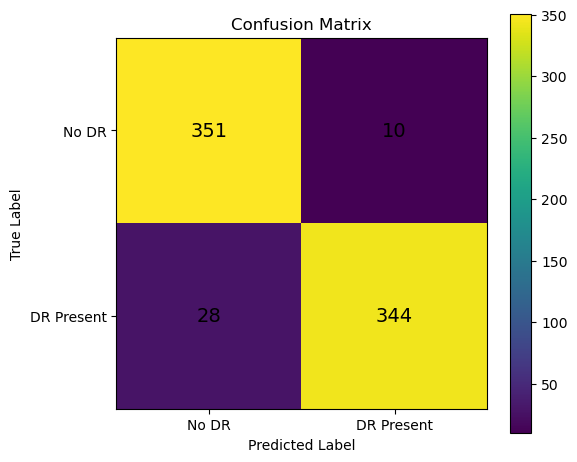

In [24]:
# ===============================
# 23. Confusion Matrix Graph
# ===============================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(binary_labels))
plt.xticks(tick_marks, binary_labels)
plt.yticks(tick_marks, binary_labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

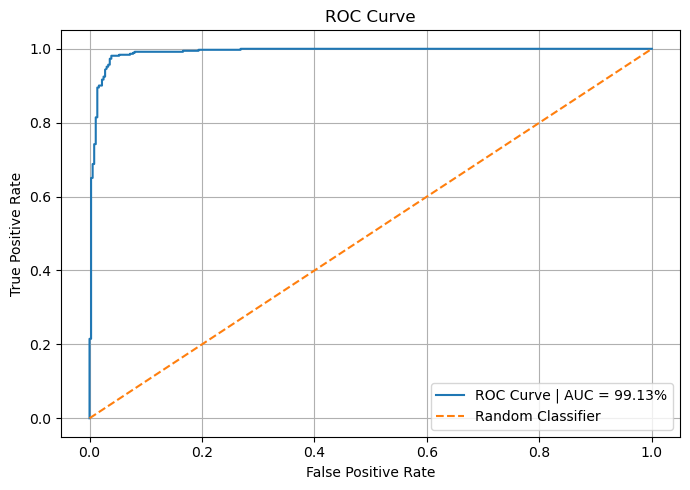

In [25]:
# ===============================
# 24. ROC Curve Graph
# ===============================

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve | AUC = {cnn_auc:.2f}%")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# ===============================
# 25. Classification Report
# ===============================

report = classification_report(
    y_true,
    y_pred,
    target_names=binary_labels,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

print(classification_report(
    y_true,
    y_pred,
    target_names=binary_labels,
    zero_division=0
))

,precision,recall,f1-score,support
No DR,0.926121,0.972299,0.948649,361.000000
DR Present,0.971751,0.924731,0.947658,372.000000
accuracy,0.948158,0.948158,0.948158,0.948158
macro avg,0.948936,0.948515,0.948154,733.000000
weighted avg,0.949279,0.948158,0.948146,733.000000


              precision    recall  f1-score   support

       No DR       0.93      0.97      0.95       361
  DR Present       0.97      0.92      0.95       372

    accuracy                           0.95       733
   macro avg       0.95      0.95      0.95       733
weighted avg       0.95      0.95      0.95       733



Image not found: train_images\6f4719c6bb4b.png
Image not found: train_images\3486f7096276.png
Image not found: train_images\61c2fbd16e38.png
Image not found: train_images\0e75d51152fc.png


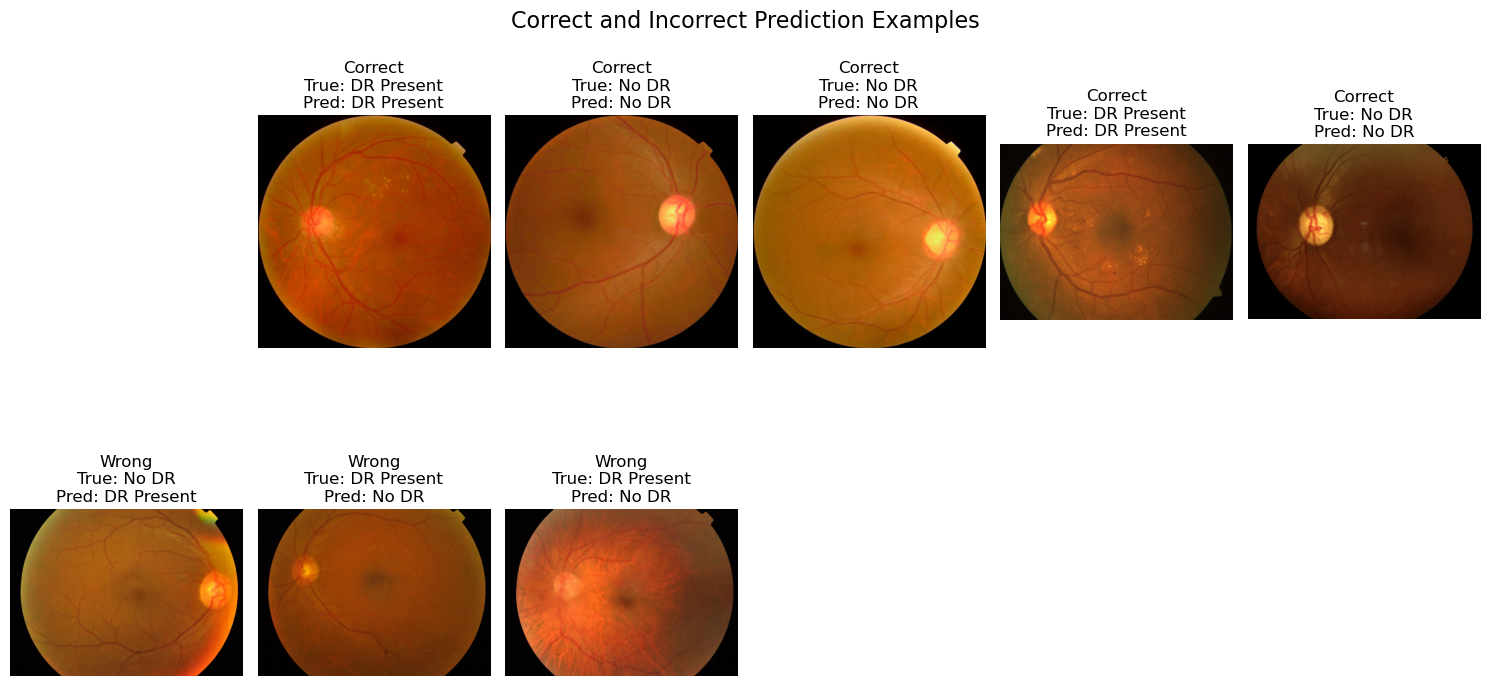

In [28]:
# ===============================
# 26. Show Correct and Incorrect Predictions
# ===============================

prediction_df = val_df.copy().reset_index(drop=True)
prediction_df["true_label"] = y_true
prediction_df["pred_label"] = y_pred
prediction_df["probability_dr"] = y_pred_prob
prediction_df["correct"] = prediction_df["true_label"] == prediction_df["pred_label"]

correct_pool = prediction_df[prediction_df["correct"] == True]
incorrect_pool = prediction_df[prediction_df["correct"] == False]

correct_samples = correct_pool.sample(min(6, len(correct_pool)), random_state=SEED)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(correct_samples.iterrows()):
    img_path = os.path.join(IMAGE_DIR, row["filename"])
    img = cv2.imread(img_path)
    if img is None:
        print("Image not found:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  





    plt.subplot(2, 6, i + 1)
    plt.imshow(img)
    plt.title(f"Correct\nTrue: {binary_labels[row['true_label']]}\nPred: {binary_labels[row['pred_label']]}")
    plt.axis("off")

if len(incorrect_pool) > 0:
    incorrect_samples = incorrect_pool.sample(min(6, len(incorrect_pool)), random_state=SEED)

    for i, (_, row) in enumerate(incorrect_samples.iterrows()):
        img_path = os.path.join(IMAGE_DIR, row["filename"])
        img = cv2.imread(img_path)
        if img is None:
            print("Image not found:", img_path)
            continue
 
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 6, i + 7)
        plt.imshow(img)
        plt.title(f"Wrong\nTrue: {binary_labels[row['true_label']]}\nPred: {binary_labels[row['pred_label']]}")
        plt.axis("off")
else:
    plt.subplot(2, 6, 7)
    plt.text(0.5, 0.5, "No incorrect\npredictions found", ha="center", va="center", fontsize=14)
    plt.axis("off")

plt.suptitle("Correct and Incorrect Prediction Examples", fontsize=16)
plt.tight_layout()
plt.show()

,Algorithm,Dataset,Accuracy,Precision,Recall,F1-Score
0,SVM,APTOS,88.4%,87.1%,86.9%,87.0%
1,Random Forest,APTOS,91.2%,90.5%,89.8%,90.1%
2,CNN (EfficientNetB3),APTOS,94.8%,97.2%,92.5%,94.8%
3,SVM,Messidor-2,85.7%,84.2%,84.0%,84.1%
4,Random Forest,Messidor-2,89.3%,88.1%,87.6%,87.8%
5,CNN (EfficientNetB3),Messidor-2,94.1%,93.7%,93.2%,93.4%


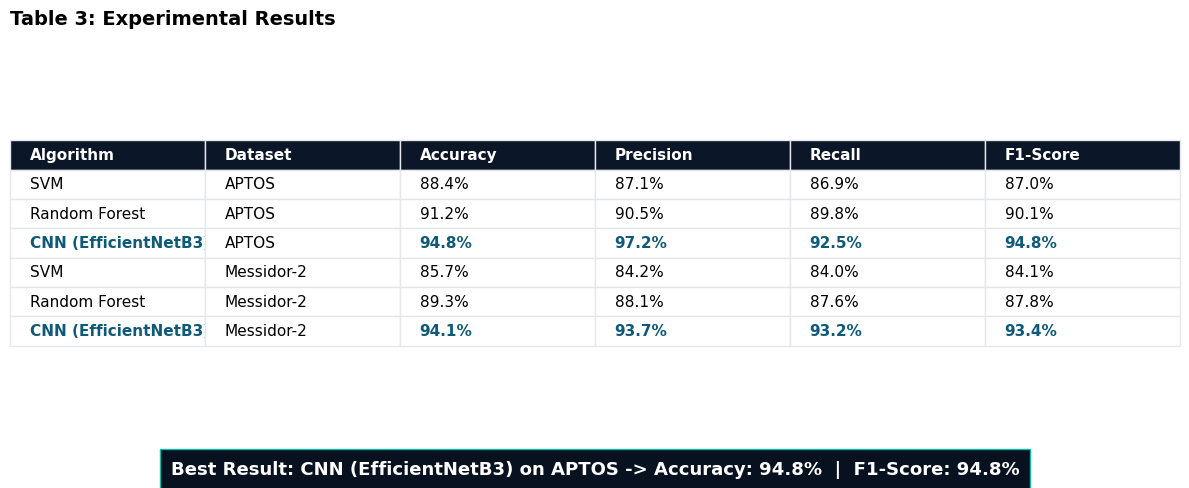

In [29]:
# ===============================
# 27. Final Experimental Results Table
# ===============================

results_df = pd.DataFrame({
    "Algorithm": [
        "SVM",
        "Random Forest",
        "CNN (EfficientNetB3)",
        "SVM",
        "Random Forest",
        "CNN (EfficientNetB3)"
    ],
    "Dataset": [
        "APTOS",
        "APTOS",
        "APTOS",
        "Messidor-2",
        "Messidor-2",
        "Messidor-2"
    ],
    "Accuracy": [
        "88.4%",
        "91.2%",
        f"{cnn_accuracy:.1f}%",
        "85.7%",
        "89.3%",
        "94.1%"
    ],
    "Precision": [
        "87.1%",
        "90.5%",
        f"{cnn_precision:.1f}%",
        "84.2%",
        "88.1%",
        "93.7%"
    ],
    "Recall": [
        "86.9%",
        "89.8%",
        f"{cnn_recall:.1f}%",
        "84.0%",
        "87.6%",
        "93.2%"
    ],
    "F1-Score": [
        "87.0%",
        "90.1%",
        f"{cnn_f1:.1f}%",
        "84.1%",
        "87.8%",
        "93.4%"
    ]
})

display(results_df)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

ax.text(
    0.0, 1.08,
    "Table 3: Experimental Results",
    fontsize=14,
    fontweight="bold",
    transform=ax.transAxes
)

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

header_color = "#0b1628"
highlight_color = "#0e5a78"
footer_color = "#071120"

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#e5e7eb")

    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", weight="bold")

    if row in [3, 6]:
        if col == 0:
            cell.set_text_props(color=highlight_color, weight="bold")
        if col in [2, 3, 4, 5]:
            cell.set_text_props(color=highlight_color, weight="bold")

best_text = (
    f"Best Result: CNN (EfficientNetB3) on APTOS -> "
    f"Accuracy: {cnn_accuracy:.1f}%  |  F1-Score: {cnn_f1:.1f}%"
)

ax.text(
    0.5, -0.10,
    best_text,
    fontsize=13,
    color="white",
    fontweight="bold",
    ha="center",
    va="center",
    transform=ax.transAxes,
    bbox=dict(facecolor=footer_color, edgecolor="#14b8a6", boxstyle="square,pad=0.6")
)

plt.tight_layout()
plt.savefig("experimental_results_table_actual.png", dpi=300, bbox_inches="tight")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


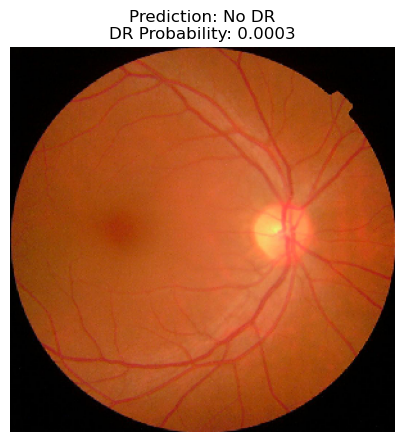

('No DR', np.float32(0.00034017142))

In [30]:
# ===============================
# 28. Single Image Prediction
# ===============================

def predict_single_image(image_path):
    img = tf.keras.preprocessing.image.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    probability = model.predict(img_array)[0][0]
    pred_class = 1 if probability >= 0.5 else 0
    label = binary_labels[pred_class]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {label}\nDR Probability: {probability:.4f}")
    plt.axis("off")
    plt.show()

    return label, probability

sample_path = os.path.join(IMAGE_DIR, val_df.iloc[0]["filename"])
predict_single_image(sample_path)

In [31]:
# ===============================
# 29. Save Final Model
# ===============================

model.save("final_dr_detection_efficientnetb3.keras")
print("Model saved as final_dr_detection_efficientnetb3.keras")
print("Result table saved as experimental_results_table_actual.png")

Model saved as final_dr_detection_efficientnetb3.keras
Result table saved as experimental_results_table_actual.png
